In [1]:
%load_ext autoreload
%autoreload 2

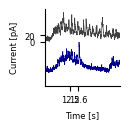

In [2]:
import scipy.io as sio
import matplotlib.pyplot as plt
import numpy as np

# Load the saved data from the .mat file
data_file_path = 'Dp_voltage_clamp_example1.mat'
mat_data = sio.loadmat(data_file_path)

# Extract variables from the loaded .mat file
data_matrix = mat_data['dataMatrix']
color_matrix = mat_data['colorMatrix']
x_data = mat_data['xData'].flatten()  # Assuming xData is a 1D array, flatten it
line_widths = mat_data['lineWidths'].flatten()  # Assuming lineWidths is a 1D array, flatten it

# Plot the data matrix in reverse order as per the original MATLAB code
figsize = (1.4,1.4)
fontsize = 6
fig, ax = plt.subplots(figsize=figsize)
# reversed_idx = range(data_matrix.shape[0] - 1, -1, -1)  # Create reversed indices similar to MATLAB's `10:-1:1`
reversed_idx = [2, 4]

linewidth = 0.5
# for idx in reversed_idx:
idx = 2
y_data_1 = - (data_matrix[idx, :]-1070)
ax.plot(x_data, y_data_1, color=color_matrix[idx, :], linewidth=linewidth)
idx = 4
y_data_2 = - (data_matrix[idx, :]-700) -80
ax.plot(x_data, y_data_2, color='darkblue', linewidth=linewidth)

# Set x-axis limits as per the MATLAB code
ax.set_xlim([12.2, 13.1])

# Set y ticks as [0, 10]
ax.set_yticks([0, 20])
# Set x ticks [12.5, 12.6]
ax.set_xticks([12.5, 12.6])

# Display the plot
ax.set_xlabel('Time [s]', fontsize=fontsize)
ax.set_ylabel('Current [pA]', fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=fontsize)

# ax.set_ylim(-2, 13)
from catrace.visualize import set_yticks_interval
#set_yticks_interval(ax, 5)

# Despine
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.tight_layout()

from catrace.for_paper import save_figure_for_paper
fig_dir = '../../figures_for_paper'
fig_name = 'Dp_voltage_clamp_example1'
save_figure_for_paper(fig, fig_name, fig_dir)